C:\Users\alper\AppData\Local\Temp\ipykernel_33144\313596981.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


Chart saved as 'popularity_league.png'.


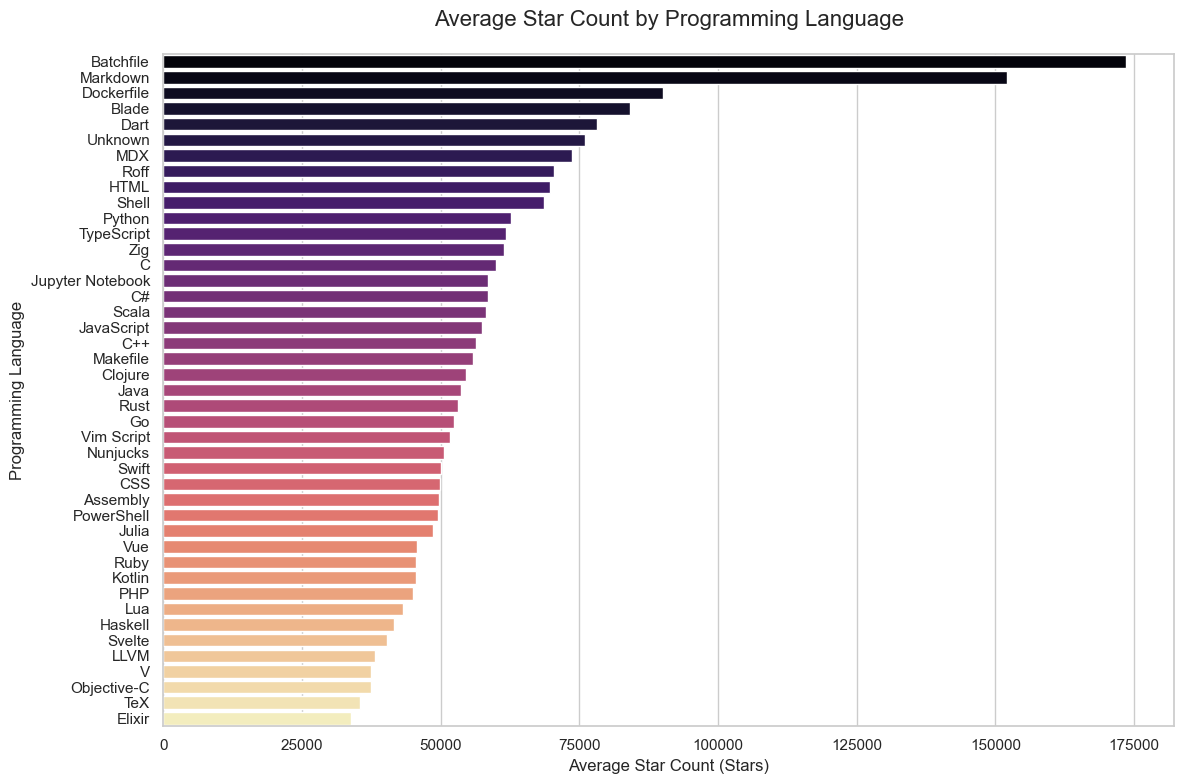

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("github_repos.csv")

avg_stars = df.groupby('language')['stars'].mean().sort_values(ascending=False).reset_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

plot = sns.barplot(
    x='stars', 
    y='language', 
    data=avg_stars, 
    palette='magma'
)

plt.title('Average Star Count by Programming Language', fontsize=16, pad=20)
plt.xlabel('Average Star Count (Stars)', fontsize=12)
plt.ylabel('Programming Language', fontsize=12)

plt.tight_layout()
plt.savefig('popularity_league.png')
print("Chart saved as 'popularity_league.png'.")
plt.show()

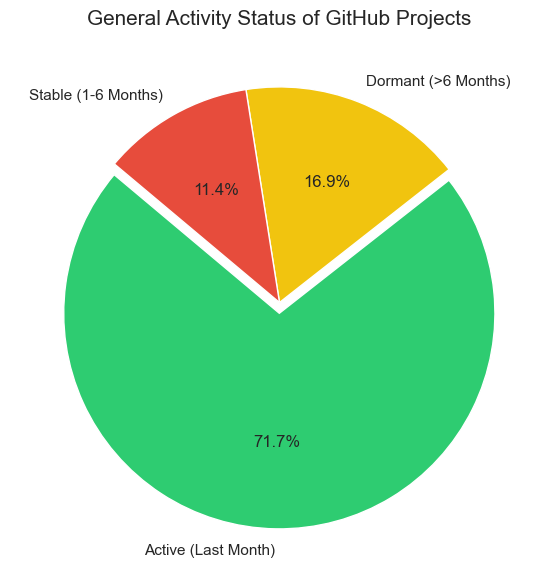

<Figure size 1400x800 with 0 Axes>

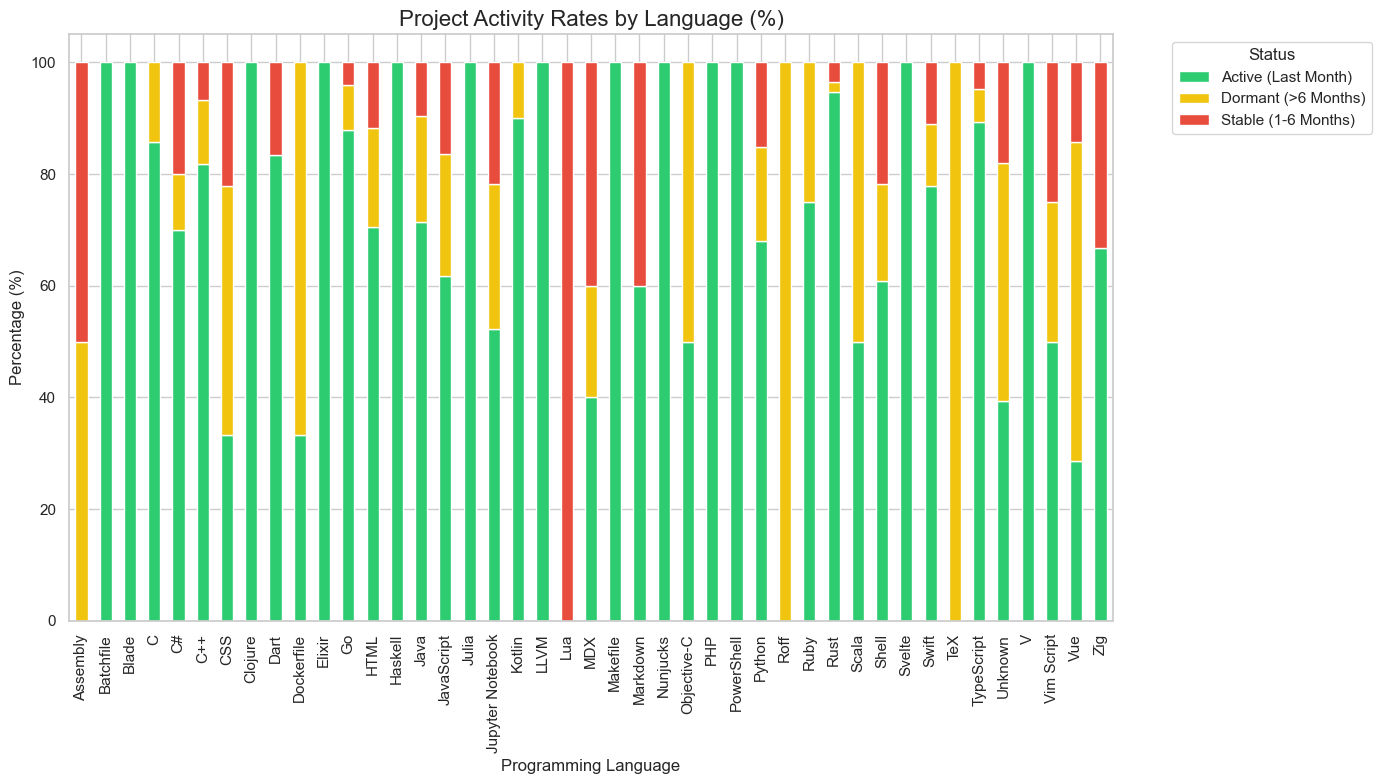

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

df = pd.read_csv("github_repos.csv")

df['pushed_at'] = pd.to_datetime(df['pushed_at'])

now = datetime.now(df['pushed_at'].dt.tz)

def check_activity(last_push):
    diff_days = (now - last_push).days
    if diff_days <= 30:
        return 'Active (Last Month)'
    elif diff_days <= 180:
        return 'Stable (1-6 Months)'
    else:
        return 'Dormant (>6 Months)'

df['activity_status'] = df['pushed_at'].apply(check_activity)

plt.figure(figsize=(10, 7))
activity_counts = df['activity_status'].value_counts()
colors = ['#2ecc71', '#f1c40f', '#e74c3c']

plt.pie(activity_counts, labels=activity_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=(0.05, 0, 0))

plt.title('General Activity Status of GitHub Projects', fontsize=15)
plt.savefig('general_activity.png')
plt.show()

plt.figure(figsize=(14, 8))
lang_activity = df.groupby(['language', 'activity_status']).size().unstack().fillna(0)
lang_activity_pct = lang_activity.div(lang_activity.sum(axis=1), axis=0) * 100

lang_activity_pct.plot(kind='bar', stacked=True, figsize=(14, 8), color=colors)
plt.title('Project Activity Rates by Language (%)', fontsize=16)
plt.ylabel('Percentage (%)')
plt.xlabel('Programming Language')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('activity_by_language.png')
plt.show()

Chart saved as 'stars_vs_issues_paneled.png'.


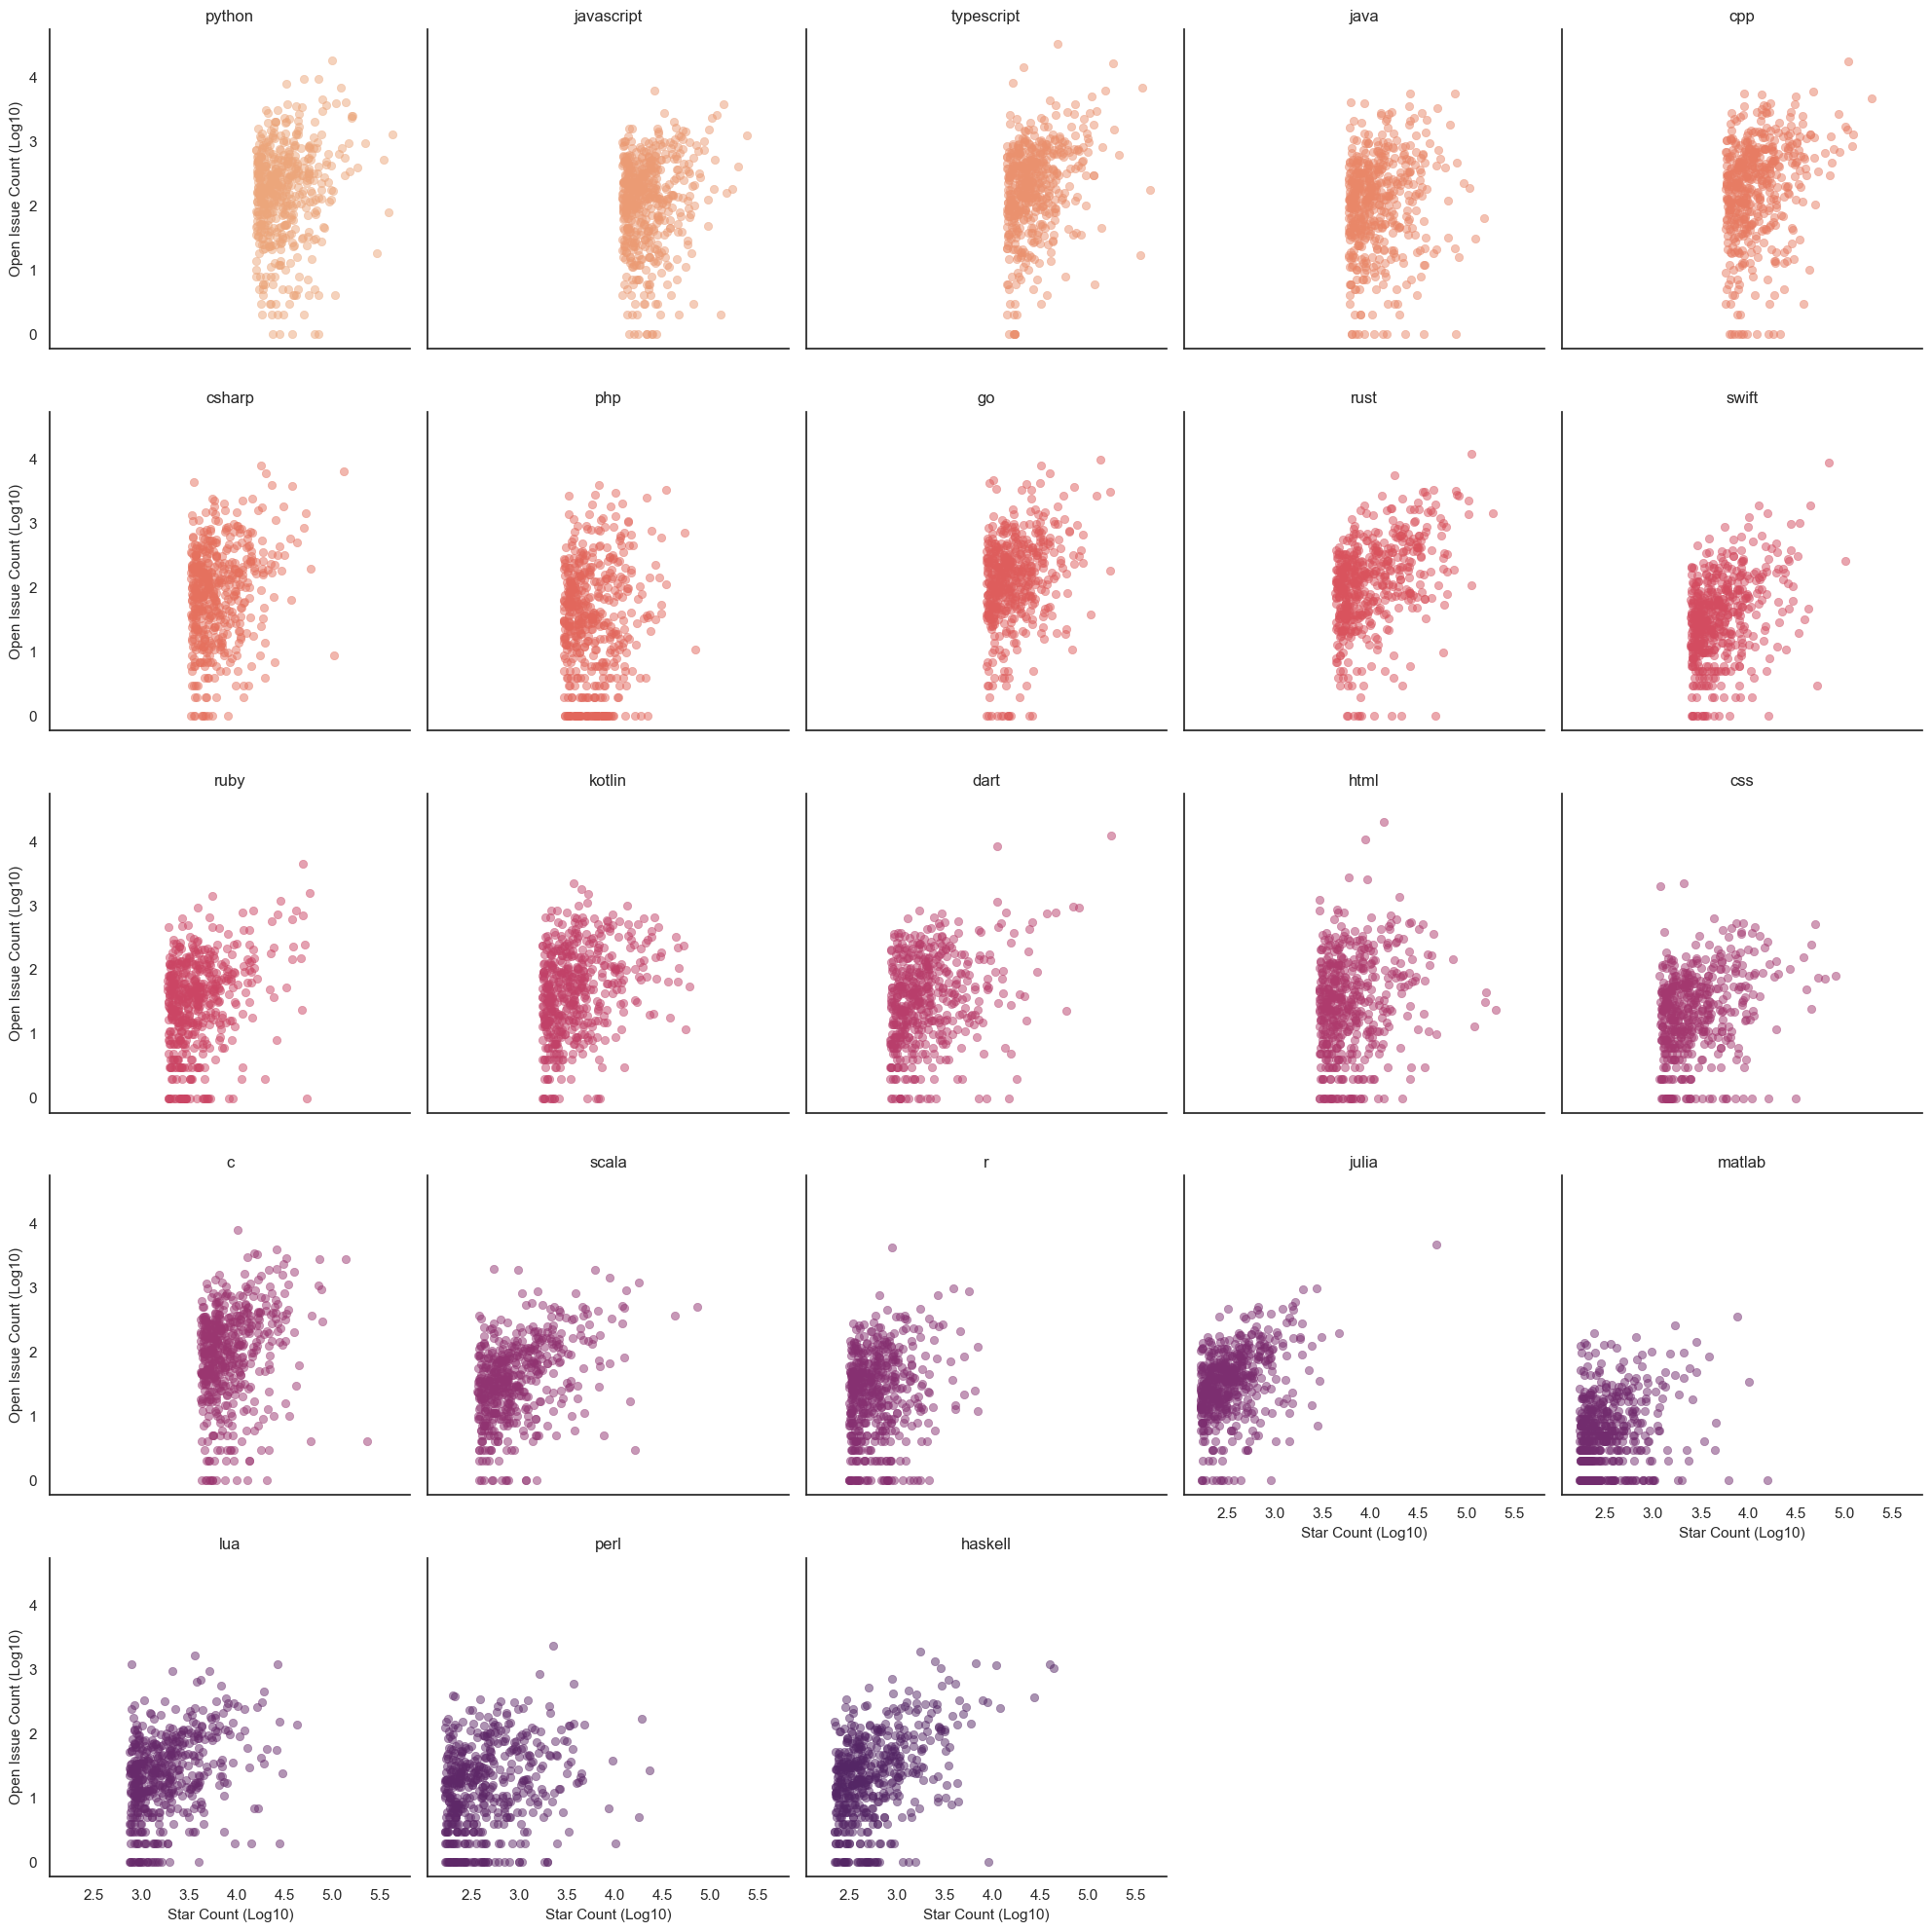

C:\Users\alper\AppData\Local\Temp\ipykernel_33144\3690835607.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='issue_density', y='language', data=density_analysis, palette='viridis')


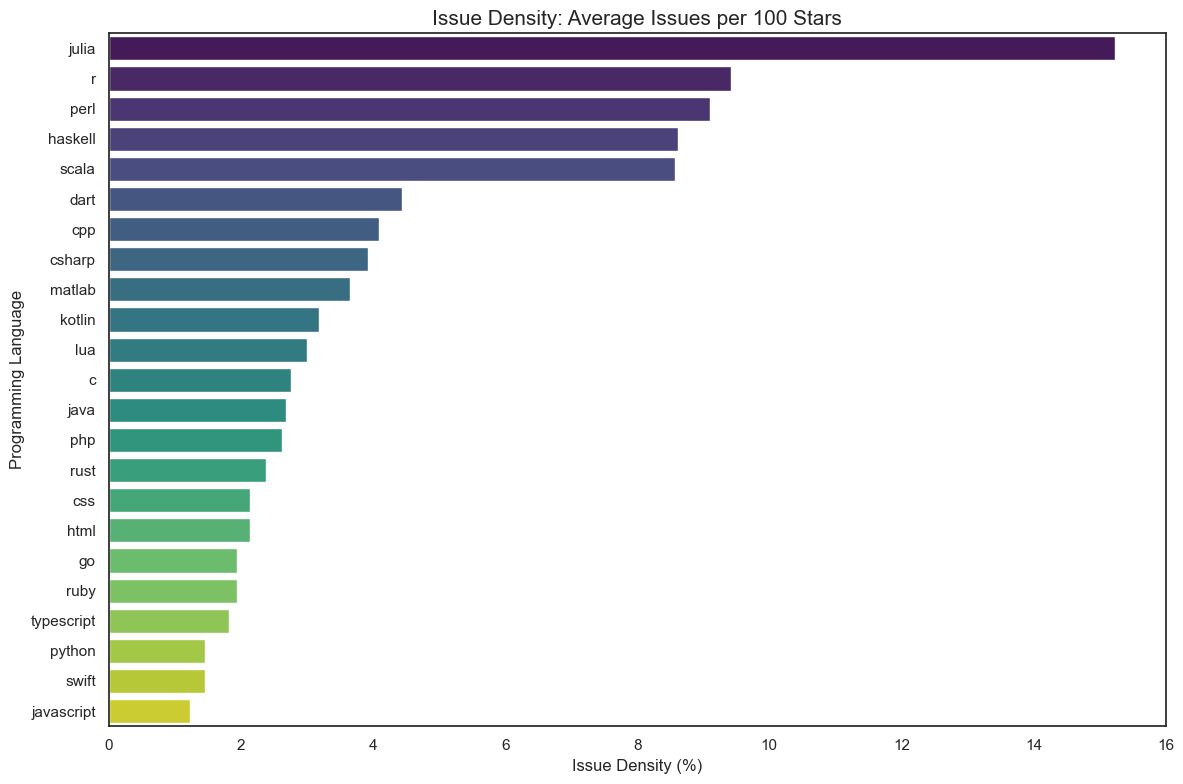

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("github_multi_lang_data.csv")

df['stars_log'] = np.log10(df['stars'] + 1)
df['issues_log'] = np.log10(df['open_issues'] + 1)

sns.set_theme(style="white")

g = sns.FacetGrid(
    df, 
    col="language",
    col_wrap=5,
    height=4,
    sharex=True,
    sharey=True,
    hue="language",
    palette="flare"
)

g.map(sns.scatterplot, "stars_log", "issues_log", alpha=0.5, edgecolor=None)

g.set_axis_labels("Star Count (Log10)", "Open Issue Count (Log10)", fontsize=11)
g.set_titles("{col_name}", fontsize=13)
g.tight_layout()

plt.savefig('stars_vs_issues_paneled.png')
print("Chart saved as 'stars_vs_issues_paneled.png'.")
plt.show()

df['issue_density'] = (df['open_issues'] / (df['stars'] + 1)) * 100

density_analysis = df.groupby('language')['issue_density'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(x='issue_density', y='language', data=density_analysis, palette='viridis')
plt.title('Issue Density: Average Issues per 100 Stars', fontsize=15)
plt.xlabel('Issue Density (%)', fontsize=12)
plt.ylabel('Programming Language', fontsize=12)
plt.tight_layout()
plt.savefig('issue_density.png')
plt.show()

Chart saved as 'corporate_ratio.png'.


<Figure size 1400x800 with 0 Axes>

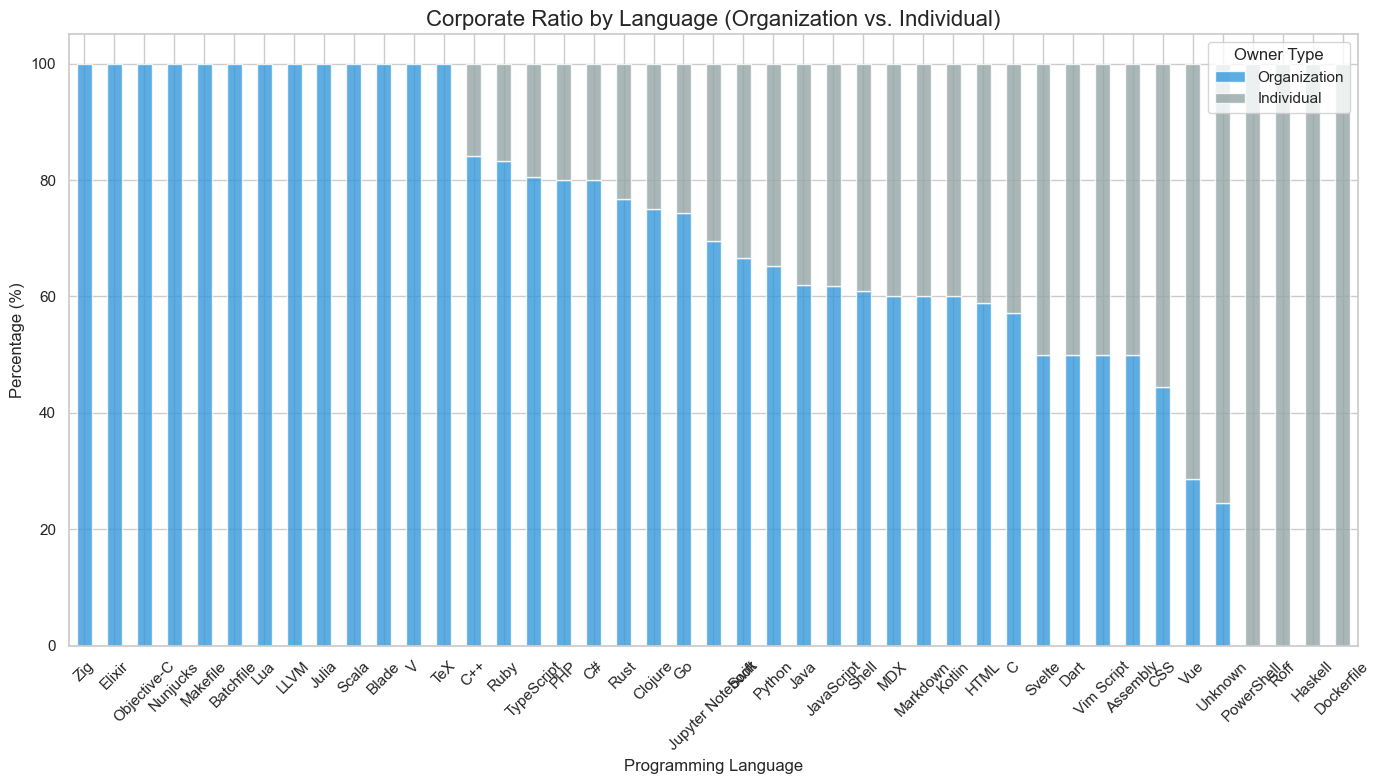

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("github_repos.csv")

owner_counts = df.groupby(['language', 'owner_type']).size().unstack(fill_value=0)

owner_pct = owner_counts.div(owner_counts.sum(axis=1), axis=0) * 100

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

owner_pct.sort_values(by='Organization', ascending=False).plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 8), 
    color=['#3498db', '#95a5a6'], 
    alpha=0.8
)

plt.title('Corporate Ratio by Language (Organization vs. Individual)', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Programming Language', fontsize=12)
plt.legend(title='Owner Type', labels=['Organization', 'Individual'], loc='upper right')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('corporate_ratio.png')
print("Chart saved as 'corporate_ratio.png'.")
plt.show()

C:\Users\alper\AppData\Local\Temp\ipykernel_33144\997667367.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Grafik 'proje_boyut_dagilimi.png' olarak kaydedildi.


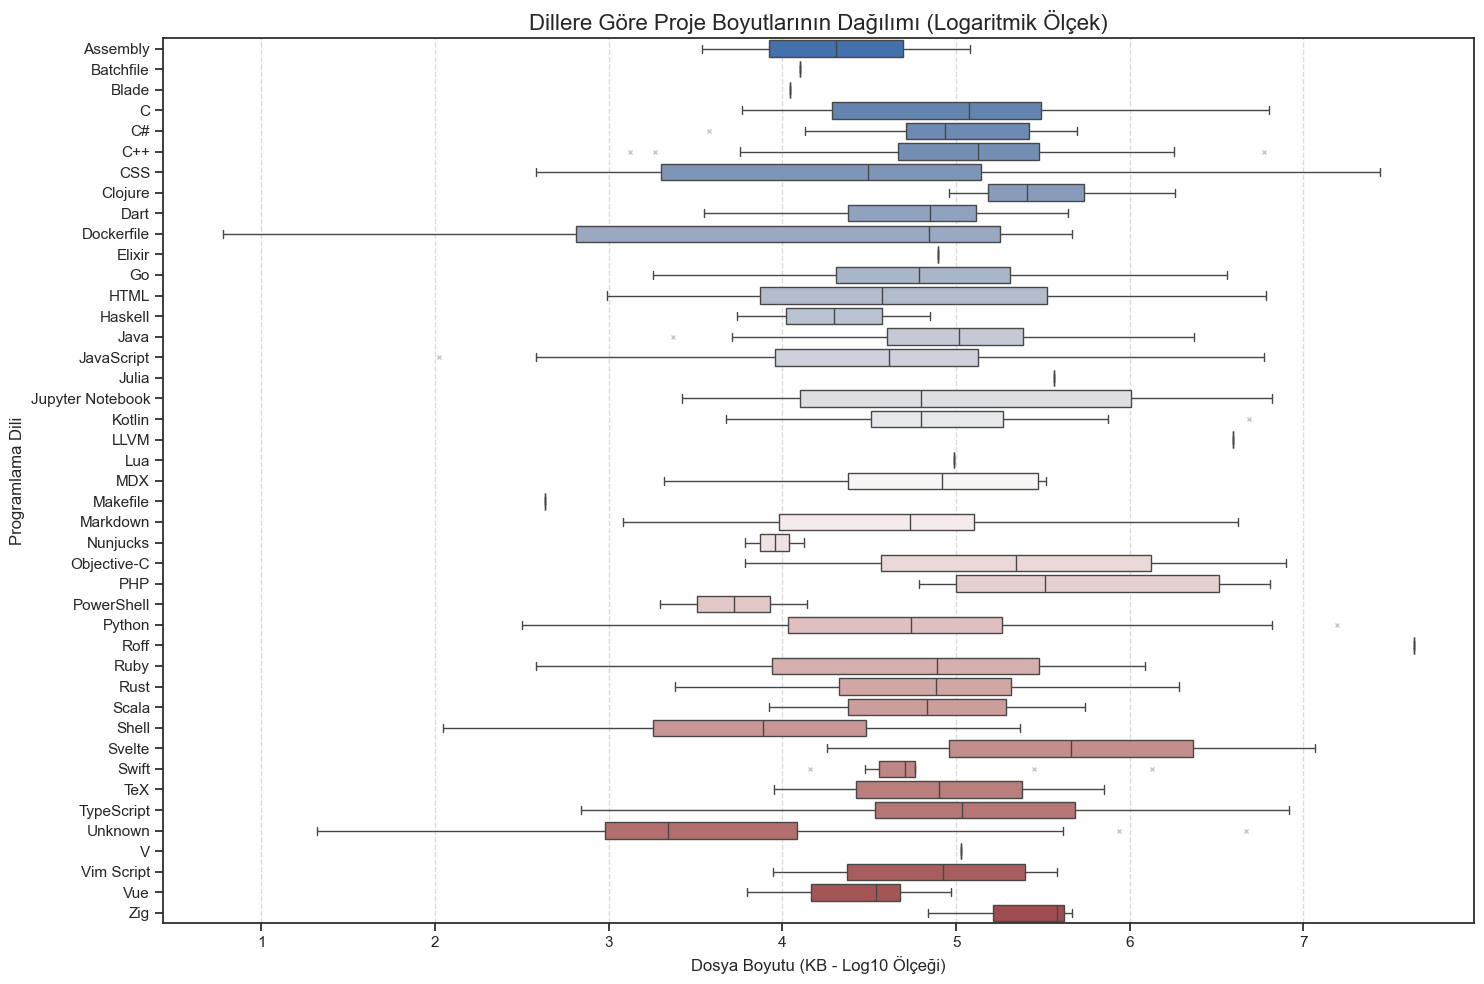

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("github_repos.csv")

df['size_log'] = np.log10(df['size'] + 1)

sns.set_theme(style="ticks")
plt.figure(figsize=(15, 10))

sns.boxplot(
    x='size_log', 
    y='language', 
    data=df.sort_values('language'),
    palette='vlag',
    flierprops={"marker": "x", "markersize": 3, "alpha": 0.3}
)

plt.title('Distribution of Project Sizes by Language (Logarithmic Scale)', fontsize=16)
plt.xlabel('File Size (KB - Log10 Scale)', fontsize=12)
plt.ylabel('Programming Language', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('project_size_distribution.png')
print("Chart saved as 'project_size_distribution.png'.")
plt.show()